In [1]:
import sys
print(sys.executable)

c:\Users\akank\anaconda3\envs\hiver\python.exe


In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/twcs/twcs.csv")

print(df.shape)
df.head()

(2811774, 7)


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [3]:
import os

print(os.getcwd())


c:\Users\akank\Desktop\code time\Hiver-Assigment\notebook


In [4]:
import os

print(os.listdir("../data/raw"))


['sample.csv', 'twcs']


In [5]:
print("Shape:", df.shape)


Shape: (2811774, 7)


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2811774 entries, 0 to 2811773
Data columns (total 7 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   tweet_id                 int64  
 1   author_id                str    
 2   inbound                  bool   
 3   created_at               str    
 4   text                     str    
 5   response_tweet_id        str    
 6   in_response_to_tweet_id  float64
dtypes: bool(1), float64(1), int64(1), str(4)
memory usage: 131.4 MB


In [7]:
df.columns.tolist()

['tweet_id',
 'author_id',
 'inbound',
 'created_at',
 'text',
 'response_tweet_id',
 'in_response_to_tweet_id']

In [8]:
df["in_response_to_tweet_id"].notna().sum()

np.int64(2017439)

In [9]:
df["author_id"].nunique()


702777

In [10]:
df["author_id"].value_counts().head(20)

author_id
AmazonHelp         169840
AppleSupport       106860
Uber_Support        56270
SpotifyCares        43265
Delta               42253
Tesco               38573
AmericanAir         36764
TMobileHelp         34317
comcastcares        33031
British_Airways     29361
SouthwestAir        28977
VirginTrains        27817
Ask_Spectrum        25860
XboxSupport         24557
sprintcare          22381
hulu_support        21872
sainsburys          19466
GWRHelp             19364
AskPlayStation      19098
ChipotleTweets      18749
Name: count, dtype: int64

In [11]:
df[["author_id", "text", "in_response_to_tweet_id"]].head(20)

,author_id,text,in_response_to_tweet_id
0,sprintcare,@115712 I understand. I would like to assist y...,3.0
1,115712,@sprintcare and how do you propose we do that,1.0
2,115712,@sprintcare I have sent several private messag...,4.0
3,sprintcare,@115712 Please send us a Private Message so th...,5.0
4,115712,@sprintcare I did.,6.0
5,sprintcare,@115712 Can you please send us a private messa...,8.0
6,115712,@sprintcare is the worst customer service,NaN
7,sprintcare,@115713 This is saddening to hear. Please shoo...,12.0
8,115713,@sprintcare You gonna magically change your co...,15.0
9,sprintcare,@115713 We understand your concerns and we'd l...,16.0


In [12]:
df.head(20)[
    ["tweet_id", "author_id", "in_response_to_tweet_id", "text"]
]

,tweet_id,author_id,in_response_to_tweet_id,text
0,1,sprintcare,3.0,@115712 I understand. I would like to assist y...
1,2,115712,1.0,@sprintcare and how do you propose we do that
2,3,115712,4.0,@sprintcare I have sent several private messag...
3,4,sprintcare,5.0,@115712 Please send us a Private Message so th...
4,5,115712,6.0,@sprintcare I did.
5,6,sprintcare,8.0,@115712 Can you please send us a private messa...
6,8,115712,NaN,@sprintcare is the worst customer service
7,11,sprintcare,12.0,@115713 This is saddening to hear. Please shoo...
8,12,115713,15.0,@sprintcare You gonna magically change your co...
9,15,sprintcare,16.0,@115713 We understand your concerns and we'd l...


In [13]:
# Identify non-numeric author IDs
brand_accounts = df[
    ~df["author_id"].astype(str).str.isnumeric()
]["author_id"].value_counts()

brand_accounts.head(30)

author_id
AmazonHelp         169840
AppleSupport       106860
Uber_Support        56270
SpotifyCares        43265
Delta               42253
Tesco               38573
AmericanAir         36764
TMobileHelp         34317
comcastcares        33031
British_Airways     29361
SouthwestAir        28977
VirginTrains        27817
Ask_Spectrum        25860
XboxSupport         24557
sprintcare          22381
hulu_support        21872
sainsburys          19466
GWRHelp             19364
AskPlayStation      19098
ChipotleTweets      18749
VerizonSupport      17966
UPSHelp             17817
ATVIAssist          17650
O2                  16212
Safaricom_Care      16077
idea_cares          15724
AskTarget           13218
AirAsiaSupport      12829
BofA_Help           12683
SW_Help             12231
Name: count, dtype: int64

In [14]:
print("Number of brand/support accounts:", len(brand_accounts))

Number of brand/support accounts: 108


In [15]:
brand_accounts.head(30)

author_id
AmazonHelp         169840
AppleSupport       106860
Uber_Support        56270
SpotifyCares        43265
Delta               42253
Tesco               38573
AmericanAir         36764
TMobileHelp         34317
comcastcares        33031
British_Airways     29361
SouthwestAir        28977
VirginTrains        27817
Ask_Spectrum        25860
XboxSupport         24557
sprintcare          22381
hulu_support        21872
sainsburys          19466
GWRHelp             19364
AskPlayStation      19098
ChipotleTweets      18749
VerizonSupport      17966
UPSHelp             17817
ATVIAssist          17650
O2                  16212
Safaricom_Care      16077
idea_cares          15724
AskTarget           13218
AirAsiaSupport      12829
BofA_Help           12683
SW_Help             12231
Name: count, dtype: int64

In [16]:
brand_reply_counts = df[
    ~df["author_id"].astype(str).str.isnumeric()
]["author_id"].value_counts()

brand_reply_counts.head(30)

author_id
AmazonHelp         169840
AppleSupport       106860
Uber_Support        56270
SpotifyCares        43265
Delta               42253
Tesco               38573
AmericanAir         36764
TMobileHelp         34317
comcastcares        33031
British_Airways     29361
SouthwestAir        28977
VirginTrains        27817
Ask_Spectrum        25860
XboxSupport         24557
sprintcare          22381
hulu_support        21872
sainsburys          19466
GWRHelp             19364
AskPlayStation      19098
ChipotleTweets      18749
VerizonSupport      17966
UPSHelp             17817
ATVIAssist          17650
O2                  16212
Safaricom_Care      16077
idea_cares          15724
AskTarget           13218
AirAsiaSupport      12829
BofA_Help           12683
SW_Help             12231
Name: count, dtype: int64

In [17]:
sprint = df[df["author_id"] == "sprintcare"]

print("SprintCare tweets:", len(sprint))
sprint[["tweet_id", "author_id", "in_response_to_tweet_id", "text"]].head(20)

SprintCare tweets: 22381


,tweet_id,author_id,in_response_to_tweet_id,text
0,1,sprintcare,3.0,@115712 I understand. I would like to assist y...
3,4,sprintcare,5.0,@115712 Please send us a Private Message so th...
5,6,sprintcare,8.0,@115712 Can you please send us a private messa...
7,11,sprintcare,12.0,@115713 This is saddening to hear. Please shoo...
9,15,sprintcare,16.0,@115713 We understand your concerns and we'd l...
11,17,sprintcare,18.0,@115713 H there! We'd definitely like to work ...
13,19,sprintcare,20.0,@115715 Please send me a private message so th...
743,1285,sprintcare,1288.0,@115950 This is really concerning to us and we...
746,1289,sprintcare,1287.0,@115950 Hi there! Service issues huh? Let us t...
749,1291,sprintcare,1293.0,@115712 Just click ‘Message’ at the top of you...


In [18]:
brand_accounts.head(30).to_dict()

{'AmazonHelp': 169840,
 'AppleSupport': 106860,
 'Uber_Support': 56270,
 'SpotifyCares': 43265,
 'Delta': 42253,
 'Tesco': 38573,
 'AmericanAir': 36764,
 'TMobileHelp': 34317,
 'comcastcares': 33031,
 'British_Airways': 29361,
 'SouthwestAir': 28977,
 'VirginTrains': 27817,
 'Ask_Spectrum': 25860,
 'XboxSupport': 24557,
 'sprintcare': 22381,
 'hulu_support': 21872,
 'sainsburys': 19466,
 'GWRHelp': 19364,
 'AskPlayStation': 19098,
 'ChipotleTweets': 18749,
 'VerizonSupport': 17966,
 'UPSHelp': 17817,
 'ATVIAssist': 17650,
 'O2': 16212,
 'Safaricom_Care': 16077,
 'idea_cares': 15724,
 'AskTarget': 13218,
 'AirAsiaSupport': 12829,
 'BofA_Help': 12683,
 'SW_Help': 12231}

In [19]:
candidates = [
    "AmazonHelp",
    "AppleSupport",
    "Uber_Support",
    "SpotifyCare",
    "Delta",
    "AmericanAir",
    "British_Airways",
    "SouthwestAir"
]

candidate_counts = brand_accounts[
    brand_accounts.index.isin(candidates)
]

candidate_counts.sort_values(ascending=False)

author_id
AmazonHelp         169840
AppleSupport       106860
Uber_Support        56270
Delta               42253
AmericanAir         36764
British_Airways     29361
SouthwestAir        28977
Name: count, dtype: int64

In [20]:
for brand in candidates:
    print("\n" + "=" * 60)
    print(brand)
    print("=" * 60)
    
    sample = df[df["author_id"] == brand][
        ["tweet_id", "author_id", "in_response_to_tweet_id", "text"]
    ].head(5)
    
    for _, row in sample.iterrows():
        print(row["text"])


AmazonHelp
@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは、どのような状況でしょうか。一般的なトラブルシューティングを記載したヘルプがございますので、ご参照ください。https://t.co/2pbG55qJ7h ET
@115770 カスタマーサービスにてお問い合わせ済みとのことで、お手数をおかけいたしました。リプライいただきありがとうございました。ET
@115770 恐れ入ります。至らない点も多々あるかとは存じますが、今後ともどうぞよろしくお願いします。ET
@115792 ご不便をおかけしております。アプリをご利用でしょうか。強制停止&gt;端末の再起動にて改善する場合がございますので、お試しください。改善しない場合は、状況を確認しご案内させていただきますのでこちらからカスタマーサービスまでご連絡ください。https://t.co/NtNAX2Qh2u ET
@115820 I'm sorry we've let you down! Without providing any personal information, will you describe the issue? We'd love to help. ^TN

AppleSupport
@115854 We're here for you. Which version of the iOS are you running? Check from Settings &gt; General &gt; About.
@115854 Lets take a closer look into this issue. Select the following link to join us in a DM and we'll go from there. https://t.co/GDrqU22YpT
@115855 Let's go to DM for the next steps. DM us here: https://t.co/GDrqU22YpT
@115855 Any steps tried since it started last night?
@115855 That's great it has iOS 11.1 as we c

In [21]:
amazon = df[df["author_id"] == "AmazonHelp"]

amazon[
    ["tweet_id", "author_id", "in_response_to_tweet_id", "text"]
].head(30)

,tweet_id,author_id,in_response_to_tweet_id,text
181,269,AmazonHelp,272.0,@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは...
184,273,AmazonHelp,271.0,@115770 カスタマーサービスにてお問い合わせ済みとのことで、お手数をおかけいたしました...
186,275,AmazonHelp,274.0,@115770 恐れ入ります。至らない点も多々あるかとは存じますが、今後ともどうぞよろしくお...
234,324,AmazonHelp,325.0,@115792 ご不便をおかけしております。アプリをご利用でしょうか。強制停止&gt;端末の...
321,615,AmazonHelp,617.0,@115820 I'm sorry we've let you down! Without ...
323,618,AmazonHelp,616.0,@115820 We'd like to take a further look into ...
326,620,AmazonHelp,621.0,@115822 I am unable to affect your account via...
328,622,AmazonHelp,624.0,"@115824 Hi, wir erhalten die Filme/Serien so v..."
330,625,AmazonHelp,623.0,@115824 Wir haben zu danken. Schönen Abend noc...
332,626,AmazonHelp,628.0,@115826 I'm sorry for the wait. You'll receive...


In [22]:
uber = df[df["author_id"] == "Uber_Support"]

uber[
    ["tweet_id", "author_id", "in_response_to_tweet_id", "text"]
].head(30)

,tweet_id,author_id,in_response_to_tweet_id,text
463,768,Uber_Support,771.0,@115872 Happy to follow up! Contact us via htt...
465,770,Uber_Support,768.0,@115872 We apologize for the trouble! Send us ...
467,772,Uber_Support,773.0,@115874 We're here to help! Send us a note her...
469,774,Uber_Support,775.0,"@115875 We’re here to help, Travis! Send us a ..."
471,776,Uber_Support,777.0,@115876 For more info about UberEats availabil...
473,778,Uber_Support,780.0,@115878 We have received your DM and will foll...
476,781,Uber_Support,782.0,@115878 We're sorry to hear this was your expe...
478,783,Uber_Support,784.0,@115880 We're sorry to hear this was your expe...
1202,1792,Uber_Support,1794.0,@116108 Here to help! Send us a note via https...
1204,1795,Uber_Support,1793.0,@116108 We're here to help! Send us a DM with ...


In [23]:
pd.set_option("display.max_colwidth", None)

amazon[
    ["tweet_id", "author_id", "in_response_to_tweet_id", "text"]
].head(10)

,tweet_id,author_id,in_response_to_tweet_id,text
181,269,AmazonHelp,272.0,@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは、どのような状況でしょうか。一般的なトラブルシューティングを記載したヘルプがございますので、ご参照ください。https://t.co/2pbG55qJ7h ET
184,273,AmazonHelp,271.0,@115770 カスタマーサービスにてお問い合わせ済みとのことで、お手数をおかけいたしました。リプライいただきありがとうございました。ET
186,275,AmazonHelp,274.0,@115770 恐れ入ります。至らない点も多々あるかとは存じますが、今後ともどうぞよろしくお願いします。ET
234,324,AmazonHelp,325.0,@115792 ご不便をおかけしております。アプリをご利用でしょうか。強制停止&gt;端末の再起動にて改善する場合がございますので、お試しください。改善しない場合は、状況を確認しご案内させていただきますのでこちらからカスタマーサービスまでご連絡ください。https://t.co/NtNAX2Qh2u ET
321,615,AmazonHelp,617.0,"@115820 I'm sorry we've let you down! Without providing any personal information, will you describe the issue? We'd love to help. ^TN"
323,618,AmazonHelp,616.0,@115820 We'd like to take a further look into this with you! Please reach us by phone or chat here: https://t.co/hApLpMlfHN ^AG
326,620,AmazonHelp,621.0,"@115822 I am unable to affect your account via Twitter. For real time support, phone or chat use this link: https://t.co/hApLpMlfHN ^CH"
328,622,AmazonHelp,624.0,"@115824 Hi, wir erhalten die Filme/Serien so vom jeweiligen Studio. Gebe ich aber direkt als Feedback dorthin weiter. Gruß ^JS"
330,625,AmazonHelp,623.0,@115824 Wir haben zu danken. Schönen Abend noch. ^JS
332,626,AmazonHelp,628.0,@115826 I'm sorry for the wait. You'll receive an email as soon as we have an estimated delivery date. ^FJ


In [24]:
tweet_lookup = df.set_index("tweet_id").to_dict("index")

In [25]:
def show_conversation(tweet_id, max_messages=10):
    conversation = []
    current_id = tweet_id

    for _ in range(max_messages):
        if current_id not in tweet_lookup:
            break

        tweet = tweet_lookup[current_id]

        conversation.append(tweet)

        parent_id = tweet["in_response_to_tweet_id"]

        if pd.isna(parent_id):
            break

        current_id = int(parent_id)

    # Reverse so oldest message comes first
    conversation.reverse()

    print("=" * 100)
    print(f"CONVERSATION ENDING AT TWEET {tweet_id}")
    print("=" * 100)

    for i, tweet in enumerate(conversation, 1):
        print(f"\nMessage {i}")
        print(f"Author: {tweet['author_id']}")
        print(f"Tweet ID: {tweet.get('tweet_id')}")
        print("-" * 80)
        print(tweet["text"])

In [26]:
show_conversation(615)

CONVERSATION ENDING AT TWEET 615

Message 1
Author: 115820
Tweet ID: None
--------------------------------------------------------------------------------
Way to drop the ball on customer service @115821 so pissed right now!

Message 2
Author: AmazonHelp
Tweet ID: None
--------------------------------------------------------------------------------
@115820 I'm sorry we've let you down! Without providing any personal information, will you describe the issue? We'd love to help. ^TN


In [27]:
amazon_tweets = df[df["author_id"] == "AmazonHelp"]

for tweet_id in amazon_tweets["tweet_id"].head(10):
    show_conversation(tweet_id)

CONVERSATION ENDING AT TWEET 269

Message 1
Author: 115770
Tweet ID: None
--------------------------------------------------------------------------------
amazonのfireTVstickが見れない😢

Message 2
Author: AmazonHelp
Tweet ID: None
--------------------------------------------------------------------------------
@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは、どのような状況でしょうか。一般的なトラブルシューティングを記載したヘルプがございますので、ご参照ください。https://t.co/2pbG55qJ7h ET
CONVERSATION ENDING AT TWEET 273

Message 1
Author: 115770
Tweet ID: None
--------------------------------------------------------------------------------
amazonのfireTVstickが見れない😢

Message 2
Author: AmazonHelp
Tweet ID: None
--------------------------------------------------------------------------------
@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは、どのような状況でしょうか。一般的なトラブルシューティングを記載したヘルプがございますので、ご参照ください。https://t.co/2pbG55qJ7h ET

Message 3
Author: 115770
Tweet ID: None
--------------------------------------------------------------------------------
@AmazonHelp 

In [28]:
tweet_lookup = df.set_index("tweet_id").to_dict("index")

In [29]:
def show_conversation(tweet_id, max_messages=10):
    conversation = []
    current_id = int(tweet_id)

    for _ in range(max_messages):
        if current_id not in tweet_lookup:
            break

        tweet = tweet_lookup[current_id]

        conversation.append((current_id, tweet))

        parent_id = tweet["in_response_to_tweet_id"]

        if pd.isna(parent_id):
            break

        current_id = int(parent_id)

    # Oldest message first
    conversation.reverse()

    print("=" * 100)
    print(f"CONVERSATION ENDING AT TWEET {tweet_id}")
    print("=" * 100)

    for i, (tid, tweet) in enumerate(conversation, 1):
        print(f"\nMessage {i}")
        print(f"Tweet ID: {tid}")
        print(f"Author: {tweet['author_id']}")
        print("-" * 80)
        print(tweet["text"])

In [30]:
show_conversation(269)

CONVERSATION ENDING AT TWEET 269

Message 1
Tweet ID: 272
Author: 115770
--------------------------------------------------------------------------------
amazonのfireTVstickが見れない😢

Message 2
Tweet ID: 269
Author: AmazonHelp
--------------------------------------------------------------------------------
@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは、どのような状況でしょうか。一般的なトラブルシューティングを記載したヘルプがございますので、ご参照ください。https://t.co/2pbG55qJ7h ET


In [31]:
show_conversation(273)

CONVERSATION ENDING AT TWEET 273

Message 1
Tweet ID: 272
Author: 115770
--------------------------------------------------------------------------------
amazonのfireTVstickが見れない😢

Message 2
Tweet ID: 269
Author: AmazonHelp
--------------------------------------------------------------------------------
@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは、どのような状況でしょうか。一般的なトラブルシューティングを記載したヘルプがございますので、ご参照ください。https://t.co/2pbG55qJ7h ET

Message 3
Tweet ID: 271
Author: 115770
--------------------------------------------------------------------------------
@AmazonHelp 電話で対応してもらいましたが改良されませんでした。
保証期間も過ぎてるので買い直しになるんでしょうね。

Message 4
Tweet ID: 273
Author: AmazonHelp
--------------------------------------------------------------------------------
@115770 カスタマーサービスにてお問い合わせ済みとのことで、お手数をおかけいたしました。リプライいただきありがとうございました。ET


In [32]:
def get_conversation_root(tweet_id, max_depth=20):
    current_id = int(tweet_id)

    for _ in range(max_depth):
        if current_id not in tweet_lookup:
            return current_id

        tweet = tweet_lookup[current_id]
        parent_id = tweet["in_response_to_tweet_id"]

        if pd.isna(parent_id):
            return current_id

        current_id = int(parent_id)

    return current_id

In [33]:
get_conversation_root(269)

272

In [34]:
root_id = get_conversation_root(269)

print("Root tweet:", root_id)
print(tweet_lookup[root_id]["text"])

Root tweet: 272
amazonのfireTVstickが見れない😢


In [35]:
uber_tweets = df[df["author_id"] == "Uber_Support"]

uber_tweets[["tweet_id", "in_response_to_tweet_id", "text"]].head(10)

,tweet_id,in_response_to_tweet_id,text
463,768,771.0,@115872 Happy to follow up! Contact us via https://t.co/1xM0TILvAI so we can connect.
465,770,768.0,@115872 We apologize for the trouble! Send us a DM with your email address and we'll connect.
467,772,773.0,"@115874 We're here to help! Send us a note here, https://t.co/WFtPA6RjWt and our team will be in touch."
469,774,775.0,"@115875 We’re here to help, Travis! Send us a note via https://t.co/dwDjAokZht and we'll be in touch."
471,776,777.0,@115876 For more info about UberEats availability click here; https://t.co/3A9YFZQFaF
473,778,780.0,@115878 We have received your DM and will follow up with you there.
476,781,782.0,@115878 We're sorry to hear this was your experience. Can you send us a DM with your email address so we can connect?
478,783,784.0,"@115880 We're sorry to hear this was your experience, Ray. Please contact us via https://t.co/aBEgvdNWQN and we'll be in touch."
1202,1792,1794.0,@116108 Here to help! Send us a note via https://t.co/xMxswVLBKT so our team can connect.
1204,1795,1793.0,@116108 We're here to help! Send us a DM with your email address so we can follow up.


In [36]:
show_conversation(770)

CONVERSATION ENDING AT TWEET 770

Message 1
Tweet ID: 771
Author: 115872
--------------------------------------------------------------------------------
@115873 you need to correct false charges from a trip in Lexington KY on Saturday. I want my $13 back #lyingdriver #theft

Message 2
Tweet ID: 768
Author: Uber_Support
--------------------------------------------------------------------------------
@115872 Happy to follow up! Contact us via https://t.co/1xM0TILvAI so we can connect.

Message 3
Tweet ID: 770
Author: Uber_Support
--------------------------------------------------------------------------------
@115872 We apologize for the trouble! Send us a DM with your email address and we'll connect.


In [37]:
apple_tweets = df[df["author_id"] == "AppleSupport"]

apple_tweets[["tweet_id", "in_response_to_tweet_id", "text"]].head(10)

,tweet_id,in_response_to_tweet_id,text
396,696,698.0,@115854 We're here for you. Which version of the iOS are you running? Check from Settings &gt; General &gt; About.
398,699,697.0,@115854 Lets take a closer look into this issue. Select the following link to join us in a DM and we'll go from there. https://t.co/GDrqU22YpT
401,701,702.0,@115855 Let's go to DM for the next steps. DM us here: https://t.co/GDrqU22YpT
403,703,704.0,@115855 Any steps tried since it started last night?
405,705,707.0,@115855 That's great it has iOS 11.1 as we can rule out being outdated. Any steps tried since this started? Do you recall when it started?
407,708,709.0,@115855 We'd like to look into this with you. Which model do you have and is iOS 11.1 installed? Any steps tried so far?
411,712,714.0,"@115856 Hey, let's work together to figure out what's going on. Meet us in DM and we'll continue from there. https://t.co/GDrqU22YpT"
414,716,717.0,@115857 We'd like to investigate further with you. Send us a DM and we can troubleshoot more from there. https://t.co/GDrqU22YpT
416,718,719.0,"@115857 Fill us in on what is happening, then we can help out from there."
418,720,721.0,@115859 We've received your DM and will continue there.


In [38]:
show_conversation(696)

CONVERSATION ENDING AT TWEET 696

Message 1
Tweet ID: 700
Author: 115854
--------------------------------------------------------------------------------
@AppleSupport why are my I️’s changing not showing up correctly on any of my social media platforms? https://t.co/GyRvpyVnkE

Message 2
Tweet ID: 698
Author: 115854
--------------------------------------------------------------------------------
@AppleSupport  https://t.co/NV0yucs0lB

Message 3
Tweet ID: 696
Author: AppleSupport
--------------------------------------------------------------------------------
@115854 We're here for you. Which version of the iOS are you running? Check from Settings &gt; General &gt; About.


In [39]:
def get_conversation(tweet_id, max_depth=15):
    messages = []
    current_id = int(tweet_id)

    for _ in range(max_depth):

        if current_id not in tweet_lookup:
            break

        tweet = tweet_lookup[current_id]

        messages.append({
            "tweet_id": current_id,
            "author": tweet["author_id"],
            "text": tweet["text"]
        })

        parent_id = tweet["in_response_to_tweet_id"]

        if pd.isna(parent_id):
            break

        current_id = int(parent_id)

    messages.reverse()

    return messages

In [40]:
def analyze_conversation(tweet_id, brand):
    conversation = get_conversation(tweet_id)

    customer_messages = []
    brand_messages = []

    for message in conversation:

        if message["author"] == brand:
            brand_messages.append(message)
        else:
            customer_messages.append(message)

    return {
        "tweet_id": tweet_id,
        "total_messages": len(conversation),
        "customer_messages": len(customer_messages),
        "brand_messages": len(brand_messages),
        "conversation": conversation
    }

In [41]:
result = analyze_conversation(696, "AppleSupport")

print("Total messages:", result["total_messages"])
print("Customer messages:", result["customer_messages"])
print("Brand messages:", result["brand_messages"])

Total messages: 3
Customer messages: 2
Brand messages: 1


In [42]:
def print_clean_conversation(tweet_id, brand):

    result = analyze_conversation(tweet_id, brand)

    print("\n" + "=" * 100)
    print(f"Conversation: {tweet_id}")
    print("=" * 100)

    for message in result["conversation"]:

        if message["author"] == brand:
            speaker = "BRAND"
        else:
            speaker = "CUSTOMER"

        print(f"\n{speaker}")
        print("-" * 50)
        print(message["text"])

In [43]:
print_clean_conversation(696, "AppleSupport")


Conversation: 696

CUSTOMER
--------------------------------------------------
@AppleSupport why are my I️’s changing not showing up correctly on any of my social media platforms? https://t.co/GyRvpyVnkE

CUSTOMER
--------------------------------------------------
@AppleSupport  https://t.co/NV0yucs0lB

BRAND
--------------------------------------------------
@115854 We're here for you. Which version of the iOS are you running? Check from Settings &gt; General &gt; About.


In [44]:
def is_useful_conversation(result):
    
    if result["customer_messages"] < 1:
        return False
    
    if result["brand_messages"] < 1:
        return False
    
    if result["total_messages"] < 2:
        return False
    
    return True

In [45]:
for brand in candidates:

    brand_tweets = df[df["author_id"] == brand]

    lengths = []

    sample_ids = brand_tweets["tweet_id"].sample(
        min(1000, len(brand_tweets)),
        random_state=42
    )

    for tweet_id in sample_ids:

        result = analyze_conversation(tweet_id, brand)

        if is_useful_conversation(result):
            lengths.append(result["total_messages"])

    print(
        brand,
        " | Avg messages:",
        round(sum(lengths) / len(lengths), 2) if lengths else 0
    )

AmazonHelp  | Avg messages: 3.99
AppleSupport  | Avg messages: 2.72
Uber_Support  | Avg messages: 2.77
SpotifyCare  | Avg messages: 0
Delta  | Avg messages: 2.81
AmericanAir  | Avg messages: 2.95
British_Airways  | Avg messages: 2.87
SouthwestAir  | Avg messages: 2.74


In [46]:
for brand in candidates:

    brand_tweets = df[df["author_id"] == brand]

    useful = 0

    for tweet_id in brand_tweets["tweet_id"].sample(
        min(1000, len(brand_tweets)),
        random_state=42
    ):
        result = analyze_conversation(tweet_id, brand)

        if is_useful_conversation(result):
            useful += 1

    print(
        brand,
        " | Tweets:", len(brand_tweets),
        " | Useful sample:", useful
    )

AmazonHelp  | Tweets: 169840  | Useful sample: 993
AppleSupport  | Tweets: 106860  | Useful sample: 998
Uber_Support  | Tweets: 56270  | Useful sample: 998
SpotifyCare  | Tweets: 0  | Useful sample: 0
Delta  | Tweets: 42253  | Useful sample: 999
AmericanAir  | Tweets: 36764  | Useful sample: 998
British_Airways  | Tweets: 29361  | Useful sample: 998
SouthwestAir  | Tweets: 28977  | Useful sample: 991


In [47]:
candidates = [
    "AmazonHelp",
    "AppleSupport",
    "Uber_Support",
    "Delta"
]


In [48]:
for brand in candidates:

    brand_tweets = df[df["author_id"] == brand]

    useful = 0

    for tweet_id in brand_tweets["tweet_id"].sample(
        min(1000, len(brand_tweets)),
        random_state=42
    ):
        result = analyze_conversation(tweet_id, brand)

        if is_useful_conversation(result):
            useful += 1

    print(
        brand,
        " | Tweets:", len(brand_tweets),
        " | Useful sample:", useful
    )

AmazonHelp  | Tweets: 169840  | Useful sample: 993
AppleSupport  | Tweets: 106860  | Useful sample: 998
Uber_Support  | Tweets: 56270  | Useful sample: 998
Delta  | Tweets: 42253  | Useful sample: 999


In [49]:
for brand in candidates:

    brand_tweets = df[df["author_id"] == brand]

    lengths = []

    sample_ids = brand_tweets["tweet_id"].sample(
        min(1000, len(brand_tweets)),
        random_state=42
    )

    for tweet_id in sample_ids:

        result = analyze_conversation(tweet_id, brand)

        if is_useful_conversation(result):
            lengths.append(result["total_messages"])

    print(
        brand,
        " | Avg messages:",
        round(sum(lengths) / len(lengths), 2) if lengths else 0
    )

AmazonHelp  | Avg messages: 3.99
AppleSupport  | Avg messages: 2.72
Uber_Support  | Avg messages: 2.77
Delta  | Avg messages: 2.81


In [50]:
def get_root_id(tweet_id, max_depth=30):
    current_id = int(tweet_id)

    for _ in range(max_depth):
        if current_id not in tweet_lookup:
            return current_id

        parent_id = tweet_lookup[current_id]["in_response_to_tweet_id"]

        if pd.isna(parent_id):
            return current_id

        current_id = int(parent_id)

    return current_id

In [51]:
print(get_root_id(269))

272


In [52]:
def get_unique_conversations(brand, sample_size=1000):
    
    brand_tweets = df[df["author_id"] == brand].copy()

    # Find root conversation for every brand tweet
    brand_tweets["conversation_id"] = brand_tweets["tweet_id"].apply(
        get_root_id
    )

    # One row per unique conversation
    conversations = brand_tweets.drop_duplicates(
        subset="conversation_id"
    )

    return conversations

In [53]:
amazon_conversations = get_unique_conversations("AmazonHelp")

print("Amazon tweets:", len(amazon))
print("Unique conversations:", len(amazon_conversations))

Amazon tweets: 169840
Unique conversations: 82921


In [54]:
def conversation_stats(brand, sample_size=1000):

    conversations = get_unique_conversations(brand)

    sample = conversations.sample(
        min(sample_size, len(conversations)),
        random_state=42
    )

    lengths = []

    for tweet_id in sample["tweet_id"]:

        conversation = get_conversation(tweet_id)

        if len(conversation) >= 2:
            lengths.append(len(conversation))

    return {
        "brand": brand,
        "unique_conversations": len(conversations),
        "sampled": len(sample),
        "avg_messages": sum(lengths) / len(lengths) if lengths else 0,
        "median_messages": pd.Series(lengths).median() if lengths else 0
    }

In [55]:
stats = []

for brand in candidates:
    stats.append(conversation_stats(brand))

stats_df = pd.DataFrame(stats)

stats_df

,brand,unique_conversations,sampled,avg_messages,median_messages
0,AmazonHelp,82921,1000,2.576,2.0
1,AppleSupport,80702,1000,2.263,2.0
2,Uber_Support,41923,1000,2.251,2.0
3,Delta,26183,1000,2.304,2.0


In [56]:
def detailed_stats(brand, sample_size=1000):

    conversations = get_unique_conversations(brand)

    sample = conversations.sample(
        min(sample_size, len(conversations)),
        random_state=42
    )

    rows = []

    for tweet_id in sample["tweet_id"]:

        result = analyze_conversation(tweet_id, brand)

        rows.append({
            "conversation_id": tweet_id,
            "total_messages": result["total_messages"],
            "customer_messages": result["customer_messages"],
            "brand_messages": result["brand_messages"]
        })

    return pd.DataFrame(rows)

In [57]:
amazon_stats = detailed_stats("AmazonHelp")

amazon_stats.describe()

,conversation_id,total_messages,customer_messages,brand_messages
count,1.000000e+03,1000.000000,1000.00000,1000.000000
mean,1.442512e+06,2.576000,1.32700,1.249000
std,8.916048e+05,1.670034,0.88705,0.840062
min,1.818000e+04,2.000000,1.00000,1.000000
25%,6.728442e+05,2.000000,1.00000,1.000000
50%,1.312457e+06,2.000000,1.00000,1.000000
75%,2.306214e+06,2.000000,1.00000,1.000000
max,2.985486e+06,15.000000,8.00000,8.000000


In [58]:
amazon_stats.head(20)

,conversation_id,total_messages,customer_messages,brand_messages
0,96626,2,1,1
1,2081551,2,1,1
2,446763,2,1,1
3,1369886,2,1,1
4,1782170,2,1,1
5,646688,4,2,2
6,419069,2,1,1
7,1022763,2,1,1
8,1098657,2,1,1
9,2901103,2,1,1


In [59]:
amazon_stats[
    amazon_stats["total_messages"] >= 4
].head(10)

,conversation_id,total_messages,customer_messages,brand_messages
5,646688,4,2,2
23,429952,4,2,2
24,2724986,11,7,4
26,65904,6,3,3
33,1273504,4,3,1
37,2807473,4,2,2
39,2835574,4,3,1
46,105300,8,4,4
49,2608099,4,2,2
56,2965254,5,3,2


In [60]:
print_clean_conversation(
    65904,
    "AmazonHelp"
)


Conversation: 65904

CUSTOMER
--------------------------------------------------
@AmazonHelp I have a delivery that was supposed to come today but still hasn’t arrived can you help please? Tracking ID Q31155496393

BRAND
--------------------------------------------------
@131075 Hey there! With Twitter, we're unable to access account or order information but we're here to help! What does your tracking information currently display here: https://t.co/aaDyEz1VgE Please, let us know. ^JE

CUSTOMER
--------------------------------------------------
@AmazonHelp It says it has been out for delivery since 8:14am today

BRAND
--------------------------------------------------
@131075 Our couriers can deliver until 21:00. Keep us posted on the delivery! ^MT

CUSTOMER
--------------------------------------------------
@AmazonHelp It said it would be delivered by 8pm today on the app

BRAND
--------------------------------------------------
@131075 Thanks for the information! Please reach out to

In [61]:
uber_stats = detailed_stats("Uber_Support")

uber_stats[
    uber_stats["total_messages"] >= 4
].head(10)

,conversation_id,total_messages,customer_messages,brand_messages
19,1384246,4,2,2
38,2356928,4,2,2
43,572639,4,2,2
63,129433,6,3,3
106,2171764,6,4,2
130,2761350,4,2,2
136,393617,6,5,1
137,378855,4,3,1
144,2744303,4,2,2
146,2106307,4,2,2


In [62]:
print_clean_conversation(
    572639,
    "Uber_Support"
)


Conversation: 572639

CUSTOMER
--------------------------------------------------
@119983 @Uber_Support @116288 @115873 Quite astounded &amp; totally disappointed by some of your business practices in India casually attributed by your support to system / driver limitations or glitches. Being forced to pay twice for the same trip repeatedly is just not on.

BRAND
--------------------------------------------------
@254555 Sorry to hear this was your experience! Please send us a note at https://t.co/DceIRNI6kV so our team can connect right away.

CUSTOMER
--------------------------------------------------
@Uber_Support I can DM you my email ID from which I have sent several messages to your support which totally describes the sequence of events &amp; my unfortunate experiences. Would that be ok?

BRAND
--------------------------------------------------
@254555 Here to help! Send us a DM with your email address and phone number so we can connect right away.


In [63]:
apple_stats = detailed_stats("AppleSupport")

apple_stats[
    apple_stats["total_messages"] >= 4
].head(10)

,conversation_id,total_messages,customer_messages,brand_messages
19,682015,5,3,2
22,1770988,4,3,1
57,1772138,4,3,1
76,1261361,4,2,2
87,2266744,4,2,2
98,1376453,4,2,2
107,1596742,4,3,1
113,2004506,4,3,1
149,1633029,4,2,2
152,2285166,4,3,1


In [64]:
print_clean_conversation(
    1261361,
    "AppleSupport"
)


Conversation: 1261361

CUSTOMER
--------------------------------------------------
@115858 every time I try to update on both my phone and iPad this happens. Any idea why? #customersupport https://t.co/paKvgnI2q8

BRAND
--------------------------------------------------
@415488 Let's help! Check out these steps here first: https://t.co/Ui1yTnOCUz Did that help get your devices updated?

CUSTOMER
--------------------------------------------------
@AppleSupport It did. Thank you! :-)

BRAND
--------------------------------------------------
@415488 We're glad to hear that's been resolved. If you need further assistance, let us know.


In [65]:
for brand in candidates:
    print(conversation_stats(brand))

{'brand': 'AmazonHelp', 'unique_conversations': 82921, 'sampled': 1000, 'avg_messages': 2.576, 'median_messages': np.float64(2.0)}
{'brand': 'AppleSupport', 'unique_conversations': 80702, 'sampled': 1000, 'avg_messages': 2.263, 'median_messages': np.float64(2.0)}
{'brand': 'Uber_Support', 'unique_conversations': 41923, 'sampled': 1000, 'avg_messages': 2.251, 'median_messages': np.float64(2.0)}
{'brand': 'Delta', 'unique_conversations': 26183, 'sampled': 1000, 'avg_messages': 2.304, 'median_messages': np.float64(2.0)}


In [66]:
def depth_distribution(brand, sample_size=5000):

    conversations = get_unique_conversations(brand)

    sample = conversations.sample(
        min(sample_size, len(conversations)),
        random_state=42
    )

    lengths = []

    for tweet_id in sample["tweet_id"]:
        conversation = get_conversation(tweet_id)

        if len(conversation) >= 2:
            lengths.append(len(conversation))

    return pd.Series(lengths).value_counts().sort_index()

In [67]:
for brand in candidates:
    print("\n", "=" * 50)
    print(brand)
    print("=" * 50)
    print(depth_distribution(brand))


AmazonHelp
2     3997
3      271
4      483
5       47
6       97
7       11
8       24
9        2
10       7
11       3
12      11
13       2
14       2
15      43
Name: count, dtype: int64

AppleSupport
2     4353
3      305
4      254
5       42
6       28
7        5
8        8
9        2
10       1
13       1
15       1
Name: count, dtype: int64

Uber_Support
2     4379
3      211
4      292
5       43
6       45
7        9
8        9
9        3
10       4
11       1
12       1
13       1
14       1
15       1
Name: count, dtype: int64

Delta
2     4220
3      212
4      447
5       32
6       52
7        7
8       12
9        1
10      10
11       1
13       1
14       1
15       4
Name: count, dtype: int64


In [68]:
def conversation_depth_metrics(brand, sample_size=5000):

    conversations = get_unique_conversations(brand)

    sample = conversations.sample(
        min(sample_size, len(conversations)),
        random_state=42
    )

    lengths = []

    for tweet_id in sample["tweet_id"]:
        length = len(get_conversation(tweet_id))

        if length >= 2:
            lengths.append(length)

    s = pd.Series(lengths)

    return {
        "brand": brand,
        "sampled": len(s),
        "avg_messages": round(s.mean(), 2),
        "median_messages": s.median(),
        "3+ messages %": round((s >= 3).mean() * 100, 2),
        "4+ messages %": round((s >= 4).mean() * 100, 2),
        "5+ messages %": round((s >= 5).mean() * 100, 2),
    }

In [69]:
depth_results = pd.DataFrame(
    [conversation_depth_metrics(brand) for brand in candidates]
)

depth_results

,brand,sampled,avg_messages,median_messages,3+ messages %,4+ messages %,5+ messages %
0,AmazonHelp,5000,2.56,2.0,20.06,14.64,4.98
1,AppleSupport,5000,2.23,2.0,12.94,6.84,1.76
2,Uber_Support,5000,2.26,2.0,12.42,8.20,2.36
3,Delta,5000,2.34,2.0,15.60,11.36,2.42


In [70]:
def build_conversation_dataset(brand):
    brand_tweets = df[df["author_id"] == brand].copy()

    # Identify the root conversation for each brand tweet
    brand_tweets["conversation_id"] = brand_tweets["tweet_id"].apply(
        get_root_id
    )

    # Keep one row per conversation
    conversations = brand_tweets.drop_duplicates(
        subset="conversation_id"
    )

    records = []

    for _, row in conversations.iterrows():

        conversation = get_conversation(
            row["tweet_id"]
        )

        customer_messages = [
            m["text"]
            for m in conversation
            if m["author"] != brand
        ]

        brand_messages = [
            m["text"]
            for m in conversation
            if m["author"] == brand
        ]

        if not customer_messages or not brand_messages:
            continue

        records.append({
            "conversation_id": row["conversation_id"],
            "customer_messages": customer_messages,
            "brand_messages": brand_messages,
            "total_messages": len(conversation),
            "conversation": conversation
        })

    return pd.DataFrame(records)

In [71]:
amazon_sample_tweets = df[
    df["author_id"] == "AmazonHelp"
].sample(
    10000,
    random_state=42
)

In [72]:
amazon_conversations.shape

(82921, 8)

In [73]:
amazon_conversations.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,conversation_id
181,269,AmazonHelp,False,Wed Nov 22 09:23:01 +0000 2017,@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは、どのような状況でしょうか。一般的なトラブルシューティングを記載したヘルプがございますので、ご参照ください。https://t.co/2pbG55qJ7h ET,"270,271",272.0,272
234,324,AmazonHelp,False,Wed Nov 22 09:06:00 +0000 2017,@115792 ご不便をおかけしております。アプリをご利用でしょうか。強制停止&gt;端末の再起動にて改善する場合がございますので、お試しください。改善しない場合は、状況を確認しご案内させていただきますのでこちらからカスタマーサービスまでご連絡ください。https://t.co/NtNAX2Qh2u ET,NaN,325.0,325
321,615,AmazonHelp,False,Tue Oct 31 22:29:00 +0000 2017,"@115820 I'm sorry we've let you down! Without providing any personal information, will you describe the issue? We'd love to help. ^TN",616,617.0,617
326,620,AmazonHelp,False,Tue Oct 31 22:28:34 +0000 2017,"@115822 I am unable to affect your account via Twitter. For real time support, phone or chat use this link: https://t.co/hApLpMlfHN ^CH",NaN,621.0,621
328,622,AmazonHelp,False,Tue Oct 31 22:28:00 +0000 2017,"@115824 Hi, wir erhalten die Filme/Serien so vom jeweiligen Studio. Gebe ich aber direkt als Feedback dorthin weiter. Gruß ^JS",623,624.0,624


In [74]:
from lingua import Language, LanguageDetectorBuilder

languages = [
    Language.ENGLISH,
    Language.JAPANESE,
    Language.SPANISH,
    Language.FRENCH,
    Language.GERMAN,
    Language.ITALIAN,
    Language.PORTUGUESE,
    Language.DUTCH
]

detector = LanguageDetectorBuilder.from_languages(*languages).build()

In [75]:
texts = [
    "I haven't received my order yet",
    "amazonのFireTVstickが見れない",
    "Mi pedido no ha llegado"
]

for text in texts:
    result = detector.detect_language_of(text)
    print(result, ":", text)

Language.ENGLISH : I haven't received my order yet
Language.JAPANESE : amazonのFireTVstickが見れない
Language.SPANISH : Mi pedido no ha llegado


In [76]:
print(df.shape)
print(df.columns.tolist())

(2811774, 7)
['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']


In [77]:
print("tweet_lookup" in globals())

True


In [78]:
def get_root_id(tweet_id, max_depth=30):
    current_id = int(tweet_id)

    for _ in range(max_depth):
        if current_id not in tweet_lookup:
            return current_id

        parent_id = tweet_lookup[current_id]["in_response_to_tweet_id"]

        if pd.isna(parent_id):
            return current_id

        current_id = int(parent_id)

    return current_id

In [79]:
amazon_replies = df[
    df["author_id"] == "AmazonHelp"
].copy()

pairs = []

for _, row in amazon_replies.iterrows():

    parent_id = row["in_response_to_tweet_id"]

    if pd.isna(parent_id):
        continue

    parent_id = int(parent_id)

    if parent_id not in tweet_lookup:
        continue

    customer = tweet_lookup[parent_id]

    # Ignore AmazonHelp → AmazonHelp replies
    if customer["author_id"] == "AmazonHelp":
        continue

    pairs.append({
        "conversation_id": get_root_id(row["tweet_id"]),
        "customer_tweet_id": parent_id,
        "brand_tweet_id": row["tweet_id"],
        "customer_text": customer["text"],
        "brand_text": row["text"]
    })

customer_pairs = pd.DataFrame(pairs)

print("Customer → AmazonHelp pairs:", len(customer_pairs))

Customer → AmazonHelp pairs: 168814


In [80]:
customer_pairs.head()

,conversation_id,customer_tweet_id,brand_tweet_id,customer_text,brand_text
0,272,272,269,amazonのfireTVstickが見れない😢,@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは、どのような状況でしょうか。一般的なトラブルシューティングを記載したヘルプがございますので、ご参照ください。https://t.co/2pbG55qJ7h ET
1,272,271,273,@AmazonHelp 電話で対応してもらいましたが改良されませんでした。\n保証期間も過ぎてるので買い直しになるんでしょうね。,@115770 カスタマーサービスにてお問い合わせ済みとのことで、お手数をおかけいたしました。リプライいただきありがとうございました。ET
2,272,274,275,@AmazonHelp こちらこそありがとうございました。,@115770 恐れ入ります。至らない点も多々あるかとは存じますが、今後ともどうぞよろしくお願いします。ET
3,325,325,324,amazonプライムビデオ、再生エラーが多いです,@115792 ご不便をおかけしております。アプリをご利用でしょうか。強制停止&gt;端末の再起動にて改善する場合がございますので、お試しください。改善しない場合は、状況を確認しご案内させていただきますのでこちらからカスタマーサービスまでご連絡ください。https://t.co/NtNAX2Qh2u ET
4,617,617,615,Way to drop the ball on customer service @115821 so pissed right now!,"@115820 I'm sorry we've let you down! Without providing any personal information, will you describe the issue? We'd love to help. ^TN"


In [81]:
customer_pairs[
    ["customer_text", "brand_text"]
].head(10)

,customer_text,brand_text
0,amazonのfireTVstickが見れない😢,@115770 こんにちは、アマゾン公式です。Fire TV Stickが見れないというのは、どのような状況でしょうか。一般的なトラブルシューティングを記載したヘルプがございますので、ご参照ください。https://t.co/2pbG55qJ7h ET
1,@AmazonHelp 電話で対応してもらいましたが改良されませんでした。\n保証期間も過ぎてるので買い直しになるんでしょうね。,@115770 カスタマーサービスにてお問い合わせ済みとのことで、お手数をおかけいたしました。リプライいただきありがとうございました。ET
2,@AmazonHelp こちらこそありがとうございました。,@115770 恐れ入ります。至らない点も多々あるかとは存じますが、今後ともどうぞよろしくお願いします。ET
3,amazonプライムビデオ、再生エラーが多いです,@115792 ご不便をおかけしております。アプリをご利用でしょうか。強制停止&gt;端末の再起動にて改善する場合がございますので、お試しください。改善しない場合は、状況を確認しご案内させていただきますのでこちらからカスタマーサービスまでご連絡ください。https://t.co/NtNAX2Qh2u ET
4,Way to drop the ball on customer service @115821 so pissed right now!,"@115820 I'm sorry we've let you down! Without providing any personal information, will you describe the issue? We'd love to help. ^TN"
5,"@AmazonHelp 3 different people have given 3 different answers and I still don't have my order. Says delivered Saturday, was not, I was home all day",@115820 We'd like to take a further look into this with you! Please reach us by phone or chat here: https://t.co/hApLpMlfHN ^AG
6,@115823 I want my amazon payments account CLOSED. dm me please.,"@115822 I am unable to affect your account via Twitter. For real time support, phone or chat use this link: https://t.co/hApLpMlfHN ^CH"
7,"@115825 also, beim Addams Family-Film in Prime sind Bild und Ton nicht wirklich synchron. Wie kommt's?","@115824 Hi, wir erhalten die Filme/Serien so vom jeweiligen Studio. Gebe ich aber direkt als Feedback dorthin weiter. Gruß ^JS"
8,"@AmazonHelp Okay, danke für die Info",@115824 Wir haben zu danken. Schönen Abend noch. ^JS
9,@115828 How about you guys figure out my Xbox One X project Scorpio edition first. No expected delivery or shipping date and it’s only a week away,@115826 I'm sorry for the wait. You'll receive an email as soon as we have an estimated delivery date. ^FJ


In [82]:

sample = customer_pairs.sample(100, random_state=42).copy()

sample["detected_language"] = sample["customer_text"].apply(
    lambda x: str(detector.detect_language_of(str(x)))
)

sample[
    ["customer_text", "detected_language"]
].head(30)

,customer_text,detected_language
111179,@119959 @115828 I preordered this game 14 months ago just to be sent it for the wrong console. FML... https://t.co/EMBHygMbOL,Language.ENGLISH
48116,@AmazonHelp 2ème colis qui devait arriver aujourd'hui et ne le sera pas...C'est quoi votre engagement Prime déjà?,Language.FRENCH
57695,@115821 are y’all ever gonna transfer my $50 gc on an account you closed without telling me...? jw,Language.ENGLISH
120768,@115821 dudes. You refunded me for the wrong item. I got my wine. Just not my #reesespeanutbuttercups the wine cost more! I only needed $4!,Language.ENGLISH
30203,@AmazonHelp Fuck u then why the hell u r having @AmazonHelp Twitter handle,Language.ENGLISH
27894,@AmazonHelp I had a scheduled furniture assembly yesterday which never happened. Upon calling the customer care they could not help much apart.,Language.ENGLISH
126672,@115821 don’t tell me I got guaranteed delivery and then change the date the day I’m supposed to get everything 😤,Language.ENGLISH
35418,@AmazonHelp Amazon shipping.,Language.ENGLISH
116058,@AmazonHelp just had chat with a representative and got assured delivery by 5 pm today. Lets see what happens....,Language.ENGLISH
86565,@AmazonHelp My lights all appear here but my Dots do not. Should this be where I select them to add? https://t.co/L7OX9LKLlD,Language.ENGLISH


In [83]:
from lingua import Language, LanguageDetectorBuilder

languages = [
    Language.ENGLISH,
    Language.JAPANESE,
    Language.SPANISH,
    Language.FRENCH,
    Language.GERMAN,
    Language.ITALIAN,
    Language.PORTUGUESE,
    Language.DUTCH
]

detector = LanguageDetectorBuilder.from_languages(
    *languages
).build()

In [84]:
sample = customer_pairs.sample(
    100,
    random_state=42
).copy()

sample["detected_language"] = sample["customer_text"].apply(
    lambda x: str(
        detector.detect_language_of(str(x))
    )
)

sample[
    ["customer_text", "detected_language"]
].head(30)

,customer_text,detected_language
111179,@119959 @115828 I preordered this game 14 months ago just to be sent it for the wrong console. FML... https://t.co/EMBHygMbOL,Language.ENGLISH
48116,@AmazonHelp 2ème colis qui devait arriver aujourd'hui et ne le sera pas...C'est quoi votre engagement Prime déjà?,Language.FRENCH
57695,@115821 are y’all ever gonna transfer my $50 gc on an account you closed without telling me...? jw,Language.ENGLISH
120768,@115821 dudes. You refunded me for the wrong item. I got my wine. Just not my #reesespeanutbuttercups the wine cost more! I only needed $4!,Language.ENGLISH
30203,@AmazonHelp Fuck u then why the hell u r having @AmazonHelp Twitter handle,Language.ENGLISH
27894,@AmazonHelp I had a scheduled furniture assembly yesterday which never happened. Upon calling the customer care they could not help much apart.,Language.ENGLISH
126672,@115821 don’t tell me I got guaranteed delivery and then change the date the day I’m supposed to get everything 😤,Language.ENGLISH
35418,@AmazonHelp Amazon shipping.,Language.ENGLISH
116058,@AmazonHelp just had chat with a representative and got assured delivery by 5 pm today. Lets see what happens....,Language.ENGLISH
86565,@AmazonHelp My lights all appear here but my Dots do not. Should this be where I select them to add? https://t.co/L7OX9LKLlD,Language.ENGLISH


In [85]:
print(customer_pairs.columns.tolist())

['conversation_id', 'customer_tweet_id', 'brand_tweet_id', 'customer_text', 'brand_text']


In [86]:
customer_pairs["detected_language"] = customer_pairs["customer_text"].apply(
    lambda x: str(detector.detect_language_of(str(x)))
)

In [87]:
english_count = (
    customer_pairs["detected_language"] == "Language.ENGLISH"
).sum()

print("Total:", len(customer_pairs))
print("English:", english_count)
print(
    "English %:",
    round(english_count / len(customer_pairs) * 100, 2)
)

Total: 168814
English: 130675
English %: 77.41


In [88]:
english_pairs = customer_pairs[
    customer_pairs["detected_language"] == "Language.ENGLISH"
].copy()

In [89]:
print(english_pairs.shape)

(130675, 6)


In [90]:
english_pairs["customer_length"] = (
    english_pairs["customer_text"].astype(str).str.len()
)

In [91]:
english_pairs = english_pairs[
    english_pairs["customer_length"] >= 15
].copy()

In [92]:
print("English usable pairs:", len(english_pairs))

English usable pairs: 130465


In [93]:
english_pairs.to_csv(
    "../data/processed/amazon_english_pairs.csv",
    index=False
)

In [94]:
intent_sample = english_pairs.sample(
    min(5000, len(english_pairs)),
    random_state=42
).copy()

print(intent_sample.shape)

(5000, 7)


In [95]:
for i, text in enumerate(
    intent_sample["customer_text"].head(100),
    1
):
    print(f"{i}. {text}")
    print("-" * 100)

1. @AmazonHelp No I placed it yesterday for evening delivery.
----------------------------------------------------------------------------------------------------
2. @115830 attempted delivery 😡 we are in a brightly lit office, still blatantly open and no attempt has been made to deliver, no phone call, nothing. We constantly get amazon deliveries. So annoyed it did not come today when I am still here waiting for it!!!!
----------------------------------------------------------------------------------------------------
3. @115821 @115823 @36561 Friend don't use amazon pay it's not responsible payment option
----------------------------------------------------------------------------------------------------
4. @AmazonHelp if I set up a wedding wish list, do people see my delivery address? As in if friends of friends were that way inclined could they click through to see where to rob the wedding gifts if i put the link on Facebook!?
-------------------------------------------------------

In [96]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [97]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5
)

In [98]:
X = vectorizer.fit_transform(
    intent_sample["customer_text"].astype(str)
)

print("Matrix shape:", X.shape)

Matrix shape: (5000, 2136)


In [99]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

intent_sample["cluster"] = kmeans.fit_predict(X)

In [100]:
intent_sample["cluster"].value_counts().sort_index()

cluster
0     323
1     474
2     459
3     262
4     467
5    1808
6      54
7     639
8     343
9     171
Name: count, dtype: int64

In [101]:
terms = vectorizer.get_feature_names_out()

for cluster_id in range(10):

    print("\n" + "=" * 100)
    print(f"CLUSTER {cluster_id}")
    print("=" * 100)

    center = kmeans.cluster_centers_[cluster_id]

    top_indices = center.argsort()[-10:][::-1]

    print("Keywords:")
    print(", ".join(terms[i] for i in top_indices))

    examples = intent_sample[
        intent_sample["cluster"] == cluster_id
    ]["customer_text"].head(5)

    print("\nExamples:")

    for example in examples:
        print("-", example[:500])


CLUSTER 0
Keywords:
https, 115830, amazonhelp, amazonhelp https, 115830 amazonhelp, just, packaging, delivery, parcel, ordered

Examples:
- My Order was canceled 4 unacceptable reason. D receipt was provided and I was told I could not be attended to cos of my accent.
@AmazonHelp https://t.co/thJQyD47fY
- @115830 I ordered from the UK site, now see it is in transit from the States! I purposely ordered from the UK to not get customs charges/additional VAT. What to do when I get charged?
- @AmazonHelp Are you having trouble in UK? @57880 https://t.co/DJO6MB1wWH
- @AmazonHelp Thank you! A cranky toddler is...well it’s easy to imagine. https://t.co/neFim1vJtq
- @AmazonHelp could you help me with this problem https://t.co/cTMUf4N0Pf

CLUSTER 1
Keywords:
delivery, today, delivered, amazonhelp, day, order, day delivery, package, yesterday, date

Examples:
- @AmazonHelp No I placed it yesterday for evening delivery.
- @115830 attempted delivery 😡 we are in a brightly lit office, still blatantl

In [102]:
terms = vectorizer.get_feature_names_out()

for cluster_id in sorted(intent_sample["cluster"].unique()):

    print("\n" + "=" * 80)
    print(f"CLUSTER {cluster_id}")
    print("=" * 80)

    center = kmeans.cluster_centers_[cluster_id]
    top_indices = center.argsort()[-10:][::-1]

    print("\nTop keywords:")
    print(", ".join(terms[i] for i in top_indices))

    examples = (
        intent_sample[
            intent_sample["cluster"] == cluster_id
        ]["customer_text"]
        .head(5)
    )

    print("\nExamples:")

    for i, example in enumerate(examples, 1):
        print(f"{i}. {example}")


CLUSTER 0

Top keywords:
https, 115830, amazonhelp, amazonhelp https, 115830 amazonhelp, just, packaging, delivery, parcel, ordered

Examples:
1. My Order was canceled 4 unacceptable reason. D receipt was provided and I was told I could not be attended to cos of my accent.
@AmazonHelp https://t.co/thJQyD47fY
2. @115830 I ordered from the UK site, now see it is in transit from the States! I purposely ordered from the UK to not get customs charges/additional VAT. What to do when I get charged?
3. @AmazonHelp Are you having trouble in UK? @57880 https://t.co/DJO6MB1wWH
4. @AmazonHelp Thank you! A cranky toddler is...well it’s easy to imagine. https://t.co/neFim1vJtq
5. @AmazonHelp could you help me with this problem https://t.co/cTMUf4N0Pf

CLUSTER 1

Top keywords:
delivery, today, delivered, amazonhelp, day, order, day delivery, package, yesterday, date

Examples:
1. @AmazonHelp No I placed it yesterday for evening delivery.
2. @115830 attempted delivery 😡 we are in a brightly lit offic

In [103]:
cluster_id = 9

print("=" * 80)
print(f"CLUSTER {cluster_id}")
print("=" * 80)

center = kmeans.cluster_centers_[cluster_id]
top_indices = center.argsort()[-15:][::-1]

print("\nTop keywords:")
print(", ".join(terms[i] for i in top_indices))

print("\nExamples:")

examples = intent_sample[
    intent_sample["cluster"] == cluster_id
]["customer_text"].head(15)

for i, example in enumerate(examples, 1):
    print(f"{i}. {example}")

CLUSTER 9

Top keywords:
email, amazonhelp, amazonhelp email, sent, account, email address, saying, received, sent email, got, __email__, email saying, address, amazon, reply

Examples:
1. @AmazonHelp Noonly my email address, they wanted all my card details but said I didn’t feel comfortable doing it,i can send you screenshots if you want?
2. .@115830 Clear instructions to leave items with concierge but “you were out” email. Been home all day, no call on entry system.
3. @117634 someone is spamming my kindle email addresses with random weight-loss images. Are you trying to tell me something, or is there a way I can stop this?
4. @AmazonHelp i just received an email again to say about verification details, was that from your team?
5. @AmazonHelp Email said 3-5. Why the change of goalposts now?
6. @24005  Hey i went thru the amazon thing and i did everything my order was placed and they blocked my email so can you order me an Iphone X please!?
7. @115830 Hi there, having a bit of problem

In [104]:
for cluster_id in sorted(intent_sample["cluster"].unique()):

    print("\n" + "#" * 100)
    print(f"CLUSTER {cluster_id}")
    print("#" * 100)

    examples = (
        intent_sample[
            intent_sample["cluster"] == cluster_id
        ]["customer_text"]
        .dropna()
        .head(10)
    )

    for i, text in enumerate(examples, 1):
        print(f"{i}. {text}")


####################################################################################################
CLUSTER 0
####################################################################################################
1. My Order was canceled 4 unacceptable reason. D receipt was provided and I was told I could not be attended to cos of my accent.
@AmazonHelp https://t.co/thJQyD47fY
2. @115830 I ordered from the UK site, now see it is in transit from the States! I purposely ordered from the UK to not get customs charges/additional VAT. What to do when I get charged?
3. @AmazonHelp Are you having trouble in UK? @57880 https://t.co/DJO6MB1wWH
4. @AmazonHelp Thank you! A cranky toddler is...well it’s easy to imagine. https://t.co/neFim1vJtq
5. @AmazonHelp could you help me with this problem https://t.co/cTMUf4N0Pf
6. @117634 My Grandma’s bookstore app screen on her Kindle is having this issue. We can’t figure it out! https://t.co/5g0D1AOz8x
7. Book from @115830 for my son's friend who's birthda

In [105]:
for cluster_id in [2, 3, 4]:

    print("\n" + "#" * 100)
    print(f"CLUSTER {cluster_id}")
    print("#" * 100)

    examples = (
        intent_sample[
            intent_sample["cluster"] == cluster_id
        ]["customer_text"]
        .dropna()
        .head(10)
    )

    for i, text in enumerate(examples, 1):
        print(f"{i}. {text}")


####################################################################################################
CLUSTER 2
####################################################################################################
1. @115821 @115823 @36561 Friend don't use amazon pay it's not responsible payment option
2. @115850 

Do amazon india has any control on furniture installation ??
3. @AmazonHelp I am not talking anything special. I was only ordering monthly refills from Amazon Pantry.
4. @AmazonHelp U should know its not an order id. Its a sellers shipment id for amazon warehouse appointment. Such a shame @115851
5. @AmazonHelp Par Amazon, c'est des coffrets bluray.
6. @AmazonHelp Thanku so much this unhelpful behaviour was expected from amazon thanku so much for making me feel that I am shopping at the world's most useless site.. thanku so much I have decided to Quit Amazon
7. @AmazonHelp No refund option on website. Amazon India says you can’t get a refund. What if a customer doesn’t like t

In [106]:
for cluster_id in [5, 6, 7,8,9]:

    print("\n" + "#" * 100)
    print(f"CLUSTER {cluster_id}")
    print("#" * 100)

    examples = (
        intent_sample[
            intent_sample["cluster"] == cluster_id
        ]["customer_text"]
        .dropna()
        .head(10)
    )

    for i, text in enumerate(examples, 1):
        print(f"{i}. {text}")


####################################################################################################
CLUSTER 5
####################################################################################################
1. @AmazonHelp if I set up a wedding wish list, do people see my delivery address? As in if friends of friends were that way inclined could they click through to see where to rob the wedding gifts if i put the link on Facebook!?
2. @AmazonHelp I was treated badly by cst advisor .my number was blocked when i wanted to speak to manager
3. @AmazonHelp Instead of cancelling my orders and locking my account, how about picking up a phone and calling me. Simple yet effective. I shouldn't have to tell you this
4. @AmazonHelp Hi - I've received a mail from e mail address - __email__ offering me promotional code for £5.00 is this real?
5. @AmazonHelp And now its replacement has got lost at the courier and will cost me £23 to replace and I'm only being offered £15 refund! Might as well d

In [107]:
golden_set = english_pairs.sample(
    200,
    random_state=42
).copy()

golden_set["intent"] = ""

golden_set = golden_set[
    [
        "conversation_id",
        "customer_tweet_id",
        "customer_text",
        "brand_text",
        "intent"
    ]
]

golden_set.head()

,conversation_id,customer_tweet_id,customer_text,brand_text,intent
75635,1116133,1116132,@AmazonHelp No I placed it yesterday for evening delivery.,@281304 What does the latest tracking advise Joanna - https://t.co/Jr1kcqQUJY ? ^TP,
162766,2894670,2894670,"@115830 attempted delivery 😡 we are in a brightly lit office, still blatantly open and no attempt has been made to deliver, no phone call, nothing. We constantly get amazon deliveries. So annoyed it did not come today when I am still here waiting for it!!!!","@792629 I am sorry to hear this, Liss. Was there a reason given for the missed delivery?What is the current status on the tracking?^SM",
58145,830140,830141,@115821 @115823 @36561 Friend don't use amazon pay it's not responsible payment option,@317671 I'm sorry to hear that you're upset due to an issue with pay balance. Could you let us know if 1/2^AP,
140152,2477419,2477419,"@AmazonHelp if I set up a wedding wish list, do people see my delivery address? As in if friends of friends were that way inclined could they click through to see where to rob the wedding gifts if i put the link on Facebook!?",@316750 People whom you share any wish list cannot see your personal address. ^BD,
11730,183364,183364,@115850 \n\nDo amazon india has any control on furniture installation ??,@159119 We'd like to help you in getting your issue resolved. Please contact us here: https://t.co/9mwpIdOzZn. ^ZH,


# Final Intent Taxonomy

After inspecting the K-Means clusters and representative customer messages, the clusters were treated as intent-discovery signals rather than ground-truth labels. Similar topics were merged and heterogeneous clusters were split into operational support intents.

The initial taxonomy contains the following intents:

1. delivery_issue
2. return_issue
3. refund_issue
4. product_issue
5. payment_issue
6. account_issue
7. prime_issue
8. customer_service_issue
9. order_issue
10. other

## Intent Labeling Guidelines

### 1. delivery_issue
Problems related to receiving an order, including delayed, missing, failed, or incorrectly marked deliveries.

Examples:
- "My package hasn't arrived."
- "It was supposed to arrive yesterday."
- "Amazon says delivered but I don't have it."
- "The delivery driver never came."

Exclude:
- Return pickup problems → return_issue
- Missing refund → refund_issue
- Defective product → product_issue

### 2. return_issue
Problems involving returning an item or arranging a return/pickup.

Examples:
- "My return hasn't been picked up."
- "How do I return this item?"
- "The return pickup was cancelled."

Exclude:
- Refund after a completed return → refund_issue

### 3. refund_issue
Problems concerning money that should be refunded or the status/amount of a refund.

Examples:
- "Where is my refund?"
- "I returned the item but haven't received my money."
- "The refund amount is incorrect."

### 4. product_issue
Problems with the physical/product itself.

Examples:
- "The product arrived damaged."
- "My headphones aren't working."
- "I received the wrong item."

### 5. payment_issue
Problems involving payment, charges, Amazon Pay, pending payments, or payment methods.

Examples:
- "My payment is still pending."
- "Why was I charged twice?"
- "Amazon Pay isn't working."

### 6. account_issue
Problems involving account access, login, verification, blocked accounts, or account security.

Examples:
- "I can't log into my account."
- "My Amazon account was blocked."
- "Why is Amazon asking me to verify my account?"

### 7. prime_issue
Problems specifically related to Amazon Prime membership or Prime benefits.

Examples:
- "I was charged after cancelling Prime."
- "Why is my Prime delivery late?"
- "I want to cancel my Prime membership."

### 8. customer_service_issue
Complaints or problems specifically about Amazon's customer support experience.

Examples:
- "I've called customer service five times."
- "Nobody from support is helping me."
- "How can I speak to a customer service representative?"

### 9. order_issue
General order problems that don't primarily concern delivery, returns, refunds, products, or payments.

Examples:
- "Why was my order cancelled?"
- "I need to modify my order."
- "There is a problem with my order."

### 10. other
Messages that cannot reliably be assigned to the above intents.

Examples:
- "Thanks!"
- "Yup."
- "Done."
- Greetings
- Spam
- Unrelated questions
- Ambiguous messages

In [108]:
golden_set.to_csv(
    "../data/golden/amazon_golden_set.csv",
    index=False
)

print("Golden set size:", len(golden_set))

Golden set size: 200


In [109]:
import pandas as pd

# Load our 200-message golden set
golden_set = pd.read_csv(
    "../data/golden/amazon_golden_set.csv"
)

# Make sure the intent column is text
golden_set["intent"] = golden_set["intent"].fillna("")

print("Total messages:", len(golden_set))
print("Unlabeled:", (golden_set["intent"] == "").sum())

Total messages: 200
Unlabeled: 200


In [110]:
from IPython.display import display, clear_output
import ipywidgets as widgets

intents = [
    "delivery_issue",
    "return_issue",
    "refund_issue",
    "product_issue",
    "payment_issue",
    "account_issue",
    "prime_issue",
    "customer_service_issue",
    "order_issue",
    "other"
]

current_index = 0

def show_message():
    clear_output(wait=True)

    if current_index >= len(golden_set):
        print("🎉 Golden Set labeling completed!")
        golden_set.to_csv(
            "../data/golden/amazon_golden_set.csv",
            index=False
        )
        return

    row = golden_set.iloc[current_index]

    print(f"Message {current_index + 1} / {len(golden_set)}")
    print("=" * 100)
    print(row["customer_text"])
    print("=" * 100)

    print("\nSelect the most appropriate intent:")

    for intent in intents:
        print(f"- {intent}")

    dropdown = widgets.Dropdown(
        options=intents,
        description="Intent:",
        layout=widgets.Layout(width="500px")
    )

    button = widgets.Button(
        description="Save & Next",
        button_style="success"
    )

    def save_label(b):
        global current_index

        golden_set.loc[
            golden_set.index[current_index],
            "intent"
        ] = dropdown.value

        golden_set.to_csv(
            "../data/golden/amazon_golden_set.csv",
            index=False
        )

        current_index += 1
        show_message()

    button.on_click(save_label)

    display(dropdown)
    display(button)

show_message()

Message 1 / 200
@AmazonHelp No I placed it yesterday for evening delivery.

Select the most appropriate intent:
- delivery_issue
- return_issue
- refund_issue
- product_issue
- payment_issue
- account_issue
- prime_issue
- customer_service_issue
- order_issue
- other


Dropdown(description='Intent:', layout=Layout(width='500px'), options=('delivery_issue', 'return_issue', 'refu…

Button(button_style='success', description='Save & Next', style=ButtonStyle())

In [1]:
intents = [
    "delivery_issue",
    "return_issue",
    "refund_issue",
    "product_issue",
    "payment_issue",
    "account_issue",
    "prime_issue",
    "customer_service_issue",
    "order_issue",
    "other"
]

print("Intent options:")
for i, intent in enumerate(intents, 1):
    print(f"{i}. {intent}")

Intent options:
1. delivery_issue
2. return_issue
3. refund_issue
4. product_issue
5. payment_issue
6. account_issue
7. prime_issue
8. customer_service_issue
9. order_issue
10. other


In [2]:
import pandas as pd

golden_set = pd.read_csv(
    "../data/golden/amazon_golden_set.csv"
)

golden_set["intent"] = golden_set["intent"].fillna("")

for i in range(len(golden_set)):

    if golden_set.loc[i, "intent"] != "":
        continue

    print("\n" + "=" * 100)
    print(f"MESSAGE {i + 1} / {len(golden_set)}")
    print("=" * 100)

    print(golden_set.loc[i, "customer_text"])

    print("\nChoose intent:")
    for j, intent in enumerate(intents, 1):
        print(f"{j}. {intent}")

    choice = input("\nEnter number (1-10): ")

    if choice.isdigit() and 1 <= int(choice) <= 10:
        golden_set.loc[i, "intent"] = intents[int(choice) - 1]

        golden_set.to_csv(
            "../data/golden/amazon_golden_set.csv",
            index=False
        )

        print("Saved:", golden_set.loc[i, "intent"])
    else:
        print("Invalid choice. Try again.")
        break


MESSAGE 1 / 200
@AmazonHelp No I placed it yesterday for evening delivery.

Choose intent:
1. delivery_issue
2. return_issue
3. refund_issue
4. product_issue
5. payment_issue
6. account_issue
7. prime_issue
8. customer_service_issue
9. order_issue
10. other
Saved: delivery_issue

MESSAGE 2 / 200
@115830 attempted delivery 😡 we are in a brightly lit office, still blatantly open and no attempt has been made to deliver, no phone call, nothing. We constantly get amazon deliveries. So annoyed it did not come today when I am still here waiting for it!!!!

Choose intent:
1. delivery_issue
2. return_issue
3. refund_issue
4. product_issue
5. payment_issue
6. account_issue
7. prime_issue
8. customer_service_issue
9. order_issue
10. other
Saved: delivery_issue

MESSAGE 3 / 200
@115821 @115823 @36561 Friend don't use amazon pay it's not responsible payment option

Choose intent:
1. delivery_issue
2. return_issue
3. refund_issue
4. product_issue
5. payment_issue
6. account_issue
7. prime_issue
8. 

In [3]:
(golden_set["intent"] != "").sum()

np.int64(100)

In [4]:
import pandas as pd

golden_set = pd.read_csv(
    "../data/golden/amazon_golden_set.csv"
)

golden_set["intent"] = golden_set["intent"].fillna("")

for i in range(len(golden_set)):

    # Skip already labeled tweets
    if golden_set.loc[i, "intent"] != "":
        continue

    print("\n" + "=" * 100)
    print(f"MESSAGE {i + 1} / {len(golden_set)}")
    print("=" * 100)

    print(golden_set.loc[i, "customer_text"])

    print("\nChoose intent:")
    for j, intent in enumerate(intents, 1):
        print(f"{j}. {intent}")

    while True:
        choice = input("\nEnter number (1-10): ")

        if choice.isdigit() and 1 <= int(choice) <= 10:
            golden_set.loc[i, "intent"] = intents[int(choice) - 1]

            golden_set.to_csv(
                "../data/golden/amazon_golden_set.csv",
                index=False
            )

            print("Saved:", golden_set.loc[i, "intent"])
            break

        else:
            print("Invalid choice. Please enter a number from 1 to 10.")


MESSAGE 101 / 200
@115821 No customer focus from Amazon...such a pathetic service Irrespective of the commitments made after escalation...🙃😛😬😠🤧

Choose intent:
1. delivery_issue
2. return_issue
3. refund_issue
4. product_issue
5. payment_issue
6. account_issue
7. prime_issue
8. customer_service_issue
9. order_issue
10. other
Saved: customer_service_issue

MESSAGE 102 / 200
@AmazonHelp Are the gift cards redeemable against Prime? Thanks for your help @AmazonHelp

Choose intent:
1. delivery_issue
2. return_issue
3. refund_issue
4. product_issue
5. payment_issue
6. account_issue
7. prime_issue
8. customer_service_issue
9. order_issue
10. other
Saved: prime_issue

MESSAGE 103 / 200
@AmazonHelp Okay great thank you

Choose intent:
1. delivery_issue
2. return_issue
3. refund_issue
4. product_issue
5. payment_issue
6. account_issue
7. prime_issue
8. customer_service_issue
9. order_issue
10. other
Saved: other

MESSAGE 104 / 200
@AmazonHelp The difference amount.. on which it was available at

In [1]:
import pandas as pd

df = pd.read_csv("../data/golden/amazon_golden_set.csv")

print(df.head())
print(df.shape)
print(df.columns)

   conversation_id  customer_tweet_id  \
0          1116133            1116132   
1          2894670            2894670   
2           830140             830141   
3          2477419            2477419   
4           183364             183364   

                                       customer_text  \
0  @AmazonHelp No I placed it yesterday for eveni...   
1  @115830 attempted delivery 😡 we are in a brigh...   
2  @115821 @115823 @36561 Friend don't use amazon...   
3  @AmazonHelp if I set up a wedding wish list, d...   
4  @115850 \r\n\r\nDo amazon india has any contro...   

                                          brand_text                  intent  
0  @281304 What does the latest tracking advise J...          delivery_issue  
1  @792629 I am sorry to hear this, Liss. Was the...          delivery_issue  
2  @317671 I'm sorry to hear that you're upset du...           payment_issue  
3  @316750 People whom you share any wish list ca...           account_issue  
4  @159119 We'd like 

In [6]:
print(df.isnull().sum())

conversation_id      0
customer_tweet_id    0
customer_text        0
brand_text           0
intent               0
dtype: int64


In [3]:
print("\nIntent distribution:")
print(df["intent"].value_counts())

print("\nDuplicate messages:",df["customer_text"].duplicated().sum())


Intent distribution:
intent
delivery_issue            55
customer_service_issue    31
other                     31
product_issue             21
account_issue             14
payment_issue             13
order_issue               13
prime_issue               11
refund_issue               7
return_issue               4
Name: count, dtype: int64

Duplicate messages: 0


In [8]:
import sys
!{sys.executable} -m pip install matplotlib

  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl (234 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   --------------------------------- ------ 2.1/2.5 MB 13.1 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 10.2 MB/s eta 0:00:00
Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl (70 kB)
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ------------- -------------------------- 2.4/7.2 MB 11.2 MB/s eta 0:00:01
   ------------------------------ --------- 5.5/7.2 MB 12.9 MB/s eta 0:00:01
   -------------

Matplotlib is building the font cache; this may take a moment.


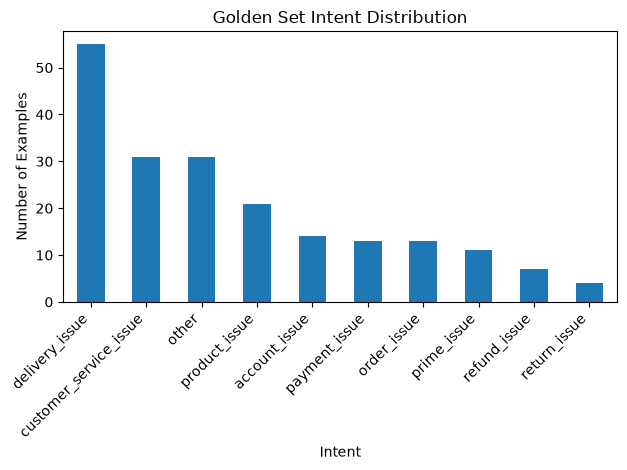

In [9]:
import matplotlib.pyplot as plt

df["intent"].value_counts().plot(kind="bar")

plt.title("Golden Set Intent Distribution")
plt.xlabel("Intent")
plt.ylabel("Number of Examples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
for intent in df["intent"].unique():
    print("\n" + "=" * 80)
    print(intent.upper())
    print("=" * 80)

    samples = df[
        df["intent"] == intent
    ]["customer_text"].sample(
        min(5, len(df[df["intent"] == intent])),
        random_state=42
    )

    for text in samples:
        print("-", text)


DELIVERY_ISSUE
- @AmazonHelp Order Id: 406-9394894-1976308 
I want this order to be delivered.i was not available at the time of delivery,
- @AmazonHelp I'm having nothing but problems with deliveries from UPS.  Great Service from Dean with DPD.  Waiting for order placed 11 Nov!  tracking info says package 'in transit'.
- @115830 Your delivery person has left a parcel that isn’t mine. How do I organise getting it returned?
- @115850 Can you please help- a gift I'd sent out is suddenly 'undeliverable' with no explanation why...Can someone please explain?
- @115830 You’re missing the point, i ordered this yesterday morning at 9am and payed for it to be here today as it stated “One Day Delivery”. If it does not turn up today i want a refund on the delivery

PAYMENT_ISSUE
- @115830 They aren’t in stock when you are letting people order the, still as they say in stock on website? Lying thieves is why
- @AmazonHelp hi, I have cancelled my amazon prime account but the payment has still been 

In [14]:
import pandas as pd

amazon_df = pd.read_csv("../data/processed/amazon_english_pairs.csv")

print(amazon_df.head())
print(amazon_df.shape)
print(amazon_df.columns)

   conversation_id  customer_tweet_id  brand_tweet_id  \
0              617                617             615   
1              617                616             618   
2              621                621             620   
3              630                628             626   
4              630                627             629   

                                       customer_text  \
0  Way to drop the ball on customer service @1158...   
1  @AmazonHelp 3 different people have given 3 di...   
2  @115823 I want my amazon payments account CLOS...   
3  @115828 How about you guys figure out my Xbox ...   
4  @AmazonHelp @115826 Yeah this is crazy we’re l...   

                                          brand_text detected_language  \
0  @115820 I'm sorry we've let you down! Without ...  Language.ENGLISH   
1  @115820 We'd like to take a further look into ...  Language.ENGLISH   
2  @115822 I am unable to affect your account via...  Language.ENGLISH   
3  @115826 I'm sorry for

In [15]:
print("\nData types:")
print(amazon_df.dtypes)

print("\nMissing values:")
print(amazon_df.isnull().sum())


Data types:
conversation_id      int64
customer_tweet_id    int64
brand_tweet_id       int64
customer_text          str
brand_text             str
detected_language      str
customer_length      int64
dtype: object

Missing values:
conversation_id      0
customer_tweet_id    0
brand_tweet_id       0
customer_text        0
brand_text           0
detected_language    0
customer_length      0
dtype: int64


In [17]:
print(df["intent"].value_counts())

intent
delivery_issue            55
customer_service_issue    31
other                     31
product_issue             21
account_issue             14
payment_issue             13
order_issue               13
prime_issue               11
refund_issue               7
return_issue               4
Name: count, dtype: int64


In [20]:
# Conversations already used in the Golden Set
golden_conversations = set(df["conversation_id"])

# Remove all Golden Set conversations from the training pool
training_pool = amazon_df[
    ~amazon_df["conversation_id"].isin(golden_conversations)
].copy()

print("Total available training messages:", len(training_pool))
print("Golden conversations excluded:", len(golden_conversations))

Total available training messages: 129629
Golden conversations excluded: 200


In [24]:
# Get all conversation IDs represented in the 200-message Golden Set
golden_conversations = set(
    df["conversation_id"].dropna().unique()
)

print("Golden conversations:", len(golden_conversations))

# Remove those conversations completely from the training pool
training_pool = amazon_df[
    ~amazon_df["conversation_id"].isin(golden_conversations)
].copy()

print("Original English pairs:", len(amazon_df))
print("Available after Golden Set exclusion:", len(training_pool))

Golden conversations: 200
Original English pairs: 130465
Available after Golden Set exclusion: 129629


In [25]:
training_1000 = training_pool.sample(
    n=1000,
    random_state=42
).reset_index(drop=True)

print("Training messages:", len(training_1000))

Training messages: 1000


In [26]:
person1 = training_1000.iloc[:500].copy()
person2 = training_1000.iloc[500:].copy()

person1["intent"] = ""
person2["intent"] = ""

print("Person 1:", len(person1))
print("Person 2:", len(person2))

Person 1: 500
Person 2: 500


In [28]:
print(
    "Golden vs Training overlap:",
    len(
        set(df["customer_tweet_id"])
        & set(training_1000["customer_tweet_id"])
    )
)

Golden vs Training overlap: 0


In [30]:
print(
    "Golden vs Training conversation overlap:",
    len(
        set(df["conversation_id"])
        & set(training_1000["conversation_id"])
    )
)

Golden vs Training conversation overlap: 0


In [31]:
person1.to_csv(
    "../data/processed/training_person1.csv",
    index=False
)

person2.to_csv(
    "../data/processed/training_person2.csv",
    index=False
)